# 05 · Scoring & Dashboard Preview

**Goal:** load the trained model, score a fresh batch of routes *at dispatch time*, and
produce the ranked daily risk list — then preview the three dashboard pages a Power BI
"Delivery Delay Risk Monitor" would show.

This is the deliverable operations actually uses: not a model, a **morning watch list**.


## 1 · Setup and load the trained model

In [15]:
import sys, os
for p in ['../src', 'src', os.path.join(os.getcwd(), 'src')]:
    if os.path.isdir(p) and p not in sys.path:
        sys.path.insert(0, p)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import data_generation as dg
import score_routes as sr

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)
pd.set_option('display.max_columns', 40)

artifact = sr.load_model()
print(f"Loaded model. Decision threshold = {artifact['threshold']:.2f} "
      f"(cost ratio {artifact['cost_ratio'][0]:.0f}:{artifact['cost_ratio'][1]:.0f})")

Loaded model. Decision threshold = 0.21 (cost ratio 3:1)


## 2 · Score "today's" routes (dispatch-time view)

We simulate a new day of 300 routes and **drop every outcome column** before scoring —
exactly what a dispatcher has at 6am when the trucks are loading.


In [16]:
today = dg.generate(n=300, seed=999)
dispatch_view = today.drop(columns=dg.LEAKAGE_COLUMNS + [dg.TARGET_COLUMN])
print("Columns available at dispatch (no outcomes):", dispatch_view.shape[1])

ranked = sr.score(dispatch_view, artifact)
print(f"\nScored {len(ranked)} routes.")
ranked.head(15)

Columns available at dispatch (no outcomes): 27

Scored 300 routes.


,route_id,route_date,dc,route_type,planned_stops,planned_miles,warehouse_load_delay_min,start_delay_min,driver_route_familiarity,delay_risk,risk_band,flagged
0,RT-000037,2025-11-28,DC_ATLANTA,suburban,24,82,101,57,1,0.912,High,1
1,RT-000138,2025-05-27,DC_CHICAGO,rural,14,159,91,44,0,0.908,High,1
2,RT-000264,2025-11-03,DC_DENVER,urban,20,54,70,41,1,0.896,High,1
3,RT-000170,2025-06-27,DC_DALLAS,urban,31,100,49,45,1,0.883,High,1
4,RT-000142,2025-01-02,DC_PHOENIX,urban,28,28,72,31,0,0.863,High,1
5,RT-000140,2025-05-06,DC_CHICAGO,urban,26,70,34,45,1,0.833,High,1
6,RT-000218,2025-09-19,DC_NEWARK,rural,16,197,41,37,1,0.831,High,1
7,RT-000018,2025-01-07,DC_DENVER,urban,26,83,66,36,1,0.824,High,1
8,RT-000080,2025-12-04,DC_DALLAS,urban,37,114,25,41,1,0.814,High,1
9,RT-000060,2025-09-17,DC_ATLANTA,urban,36,116,30,23,0,0.767,High,1


## 3 · Page 1 — Executive summary

Headline numbers + the risk mix. In Power BI these become KPI cards and a band donut.


Total routes today:        300
Flagged for review:        118  (39%)
High risk:                 39
Avg predicted delay risk:  24%


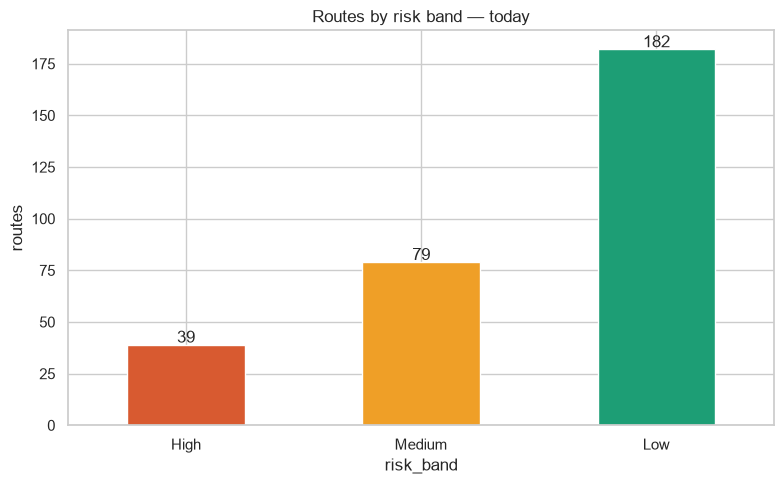

In [17]:
counts = ranked['risk_band'].value_counts().reindex(['High', 'Medium', 'Low'])
total = len(ranked)
flagged = int(ranked['flagged'].sum())

print(f"Total routes today:        {total}")
print(f"Flagged for review:        {flagged}  ({flagged/total:.0%})")
print(f"High risk:                 {counts['High']}")
print(f"Avg predicted delay risk:  {ranked['delay_risk'].mean():.0%}")

ax = counts.plot(kind='bar', color=['#D85A30', '#EF9F27', '#1D9E75'])
ax.set_ylabel('routes'); ax.set_title('Routes by risk band — today')
for i, v in enumerate(counts.values):
    ax.text(i, v + 1, str(v), ha='center')
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

### High-risk routes by DC (where to focus this morning)

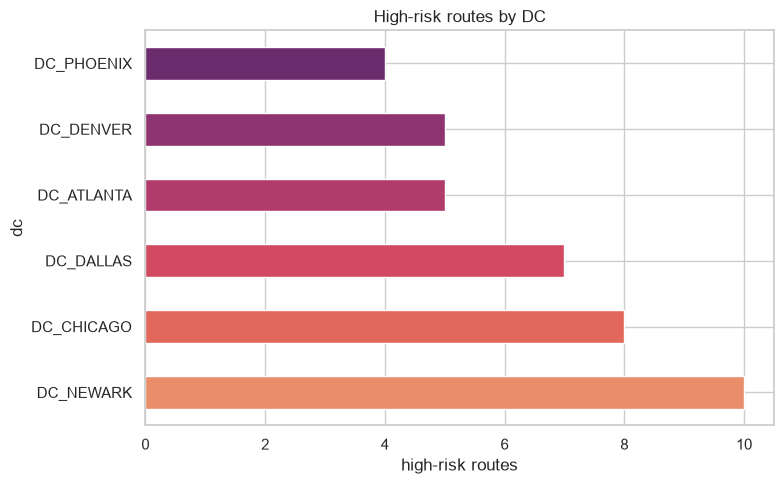

In [18]:
high = ranked[ranked['risk_band'] == 'High']
by_dc = high['dc'].value_counts()
ax = by_dc.plot(kind='barh', color=sns.color_palette('flare', len(by_dc)))
ax.set_xlabel('high-risk routes'); ax.set_title('High-risk routes by DC')
plt.tight_layout(); plt.show()

## 4 · Page 2 — Route risk detail (the watch list)

The operational table: every flagged route, ranked, with the band and the top risk factors
visible. This is what dispatch works down each morning.


In [19]:
watch = ranked[ranked['flagged'] == 1].copy()
watch_display = watch[['route_id', 'dc', 'route_type', 'planned_stops',
                       'warehouse_load_delay_min', 'start_delay_min',
                       'delay_risk', 'risk_band']].head(20)

def color_band(val):
    return {'High': 'background-color:#FAECE7',
            'Medium': 'background-color:#FAEEDA',
            'Low': 'background-color:#E1F5EE'}.get(val, '')

try:                     # pandas >= 2.1
    styled = watch_display.style.map(color_band, subset=['risk_band'])
except AttributeError:   # older pandas
    styled = watch_display.style.applymap(color_band, subset=['risk_band'])
styled.format({'delay_risk': '{:.0%}'})

,route_id,dc,route_type,planned_stops,warehouse_load_delay_min,start_delay_min,delay_risk,risk_band
0,RT-000037,DC_ATLANTA,suburban,24,101,57,91%,High
1,RT-000138,DC_CHICAGO,rural,14,91,44,91%,High
2,RT-000264,DC_DENVER,urban,20,70,41,90%,High
3,RT-000170,DC_DALLAS,urban,31,49,45,88%,High
4,RT-000142,DC_PHOENIX,urban,28,72,31,86%,High
5,RT-000140,DC_CHICAGO,urban,26,34,45,83%,High
6,RT-000218,DC_NEWARK,rural,16,41,37,83%,High
7,RT-000018,DC_DENVER,urban,26,66,36,82%,High
8,RT-000080,DC_DALLAS,urban,37,25,41,81%,High
9,RT-000060,DC_ATLANTA,urban,36,30,23,77%,High


## 5 · Page 3 — Root-cause insights

*Why* are routes risky? Risk by warehouse-load-delay bucket makes the lever obvious — the
same 4.8x story from EDA, now on live scored routes. This is the page that turns a prediction
into an action ("prioritize warehouse loading on these lanes").


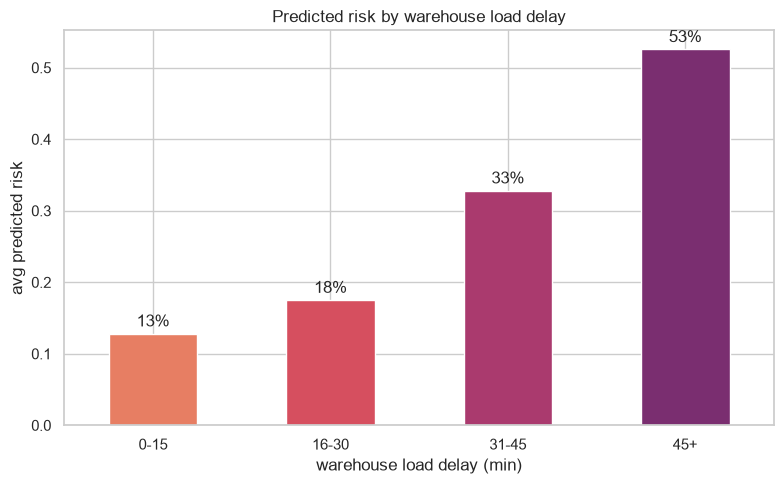

In [20]:
scored = ranked.merge(
    dispatch_view[['route_id', 'planned_stops', 'traffic_index',
                   'delivery_window_pressure']],
    on='route_id', how='left', suffixes=('', '_y'))

scored['load_delay_bucket'] = pd.cut(
    scored['warehouse_load_delay_min'], bins=[-1, 15, 30, 45, 300],
    labels=['0-15', '16-30', '31-45', '45+'])

avg_risk = scored.groupby('load_delay_bucket', observed=True)['delay_risk'].mean()
ax = avg_risk.plot(kind='bar', color=sns.color_palette('flare', len(avg_risk)))
ax.set_ylabel('avg predicted risk'); ax.set_xlabel('warehouse load delay (min)')
ax.set_title('Predicted risk by warehouse load delay')
for i, v in enumerate(avg_risk.values):
    ax.text(i, v + 0.01, f'{v:.0%}', ha='center')
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

## 6 · Save the daily risk list (the Power BI feed)

In [21]:
os.makedirs('../data/processed', exist_ok=True)
ranked.to_csv('../data/processed/daily_risk_list.csv', index=False)
print("Saved ../data/processed/daily_risk_list.csv:", ranked.shape)

PermissionError: [Errno 13] Permission denied: '../data/processed/daily_risk_list.csv'

## 7 · Connect to Power BI (your home turf)

1. **Get Data → Text/CSV** → `data/processed/daily_risk_list.csv`.
2. Build three pages mirroring the previews above:
   - **Executive Summary** — KPI cards (total, flagged, high-risk, avg risk) + band donut + high-risk-by-DC bar.
   - **Route Risk Detail** — the watch-list table, conditional-formatted by `risk_band`, sorted by `delay_risk`.
   - **Root-Cause Insights** — risk by warehouse-delay bucket, stop-count bucket, driver familiarity, DC.
3. Add a `risk_band` slicer and a `dc` slicer.
4. **Row-Level Security** by `dc` so each site sees only its routes — the exact RLS pattern
   you already run at scale.

### Where this goes next (v2 — Databricks)
Replace the CSV hop with a governed loop: features in a **Delta** table → model tracked and
registered in **MLflow** → **scheduled batch scoring** writes `daily_risk_list` back to a table
→ Power BI reads that table live with RLS. Same feature and threshold logic — just productionized.


## 8 · Project wrap-up

You built an end-to-end predictive analytics project:

1. **Business framing** with a leakage-safe design anchored to a real decision point (dispatch).
2. **Synthetic-but-realistic data** with honest noise (~25% delay rate).
3. **EDA** that surfaced the operational drivers.
4. **Feature engineering** in a reusable module with a leakage guardrail.
5. **Modeling** with a proper time-based split, and evaluation via a **cost-based threshold**,
   **calibration**, and **SHAP** — not just accuracy.
6. **Batch scoring** producing a ranked daily risk list ready for **Power BI**.

**Resume bullet:**
> Built an end-to-end delivery delay-risk prediction system on logistics-style route,
> warehouse, driver, and traffic data — engineered leakage-safe features, trained and
> calibrated classification models, selected an operating threshold by business cost
> (raising delay recall from ~44% to ~79%), and delivered a ranked daily risk feed for a
> Power BI operations dashboard.
